# t-SNE for Nonlinear Dimensionality Reduction

## Objectives

- Understand the intuition behind t-SNE.
- Apply t-SNE to high-dimensional data.
- Visualize complex datasets in 2D.
- Understand the effect of perplexity.
- Compare t-SNE with PCA.

## t-SNE Intuition

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a nonlinear
dimensionality-reduction technique primarily used for visualization.

Unlike PCA, t-SNE focuses on preserving local relationships between
data points.

Main idea:

1. Measure similarities between points in high-dimensional space.
2. Map the points into a lower-dimensional space.
3. Adjust the low-dimensional representation so that similar points
   remain close together.
4. Use a Student-t distribution in the low-dimensional space to reduce
   the crowding problem.

Important parameter:

- `perplexity`: Controls the effective number of neighboring points
  considered when constructing local relationships.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
data = load_digits()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset shape: (1797, 64)
Number of classes: 10


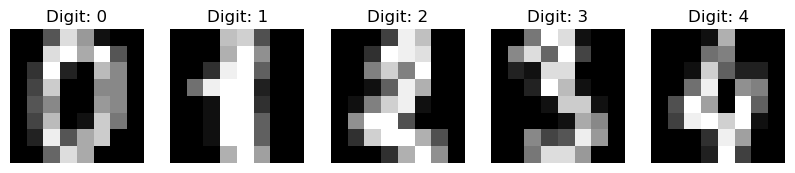

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(
        data.images[i],
        cmap="gray"
    )
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.show()

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (1797, 64)
Scaled shape: (1797, 64)


In [5]:
pca = PCA(
    n_components=30,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("Before PCA:", X_scaled.shape)
print("After PCA:", X_pca.shape)

Before PCA: (1797, 64)
After PCA: (1797, 30)


In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (1797, 2)


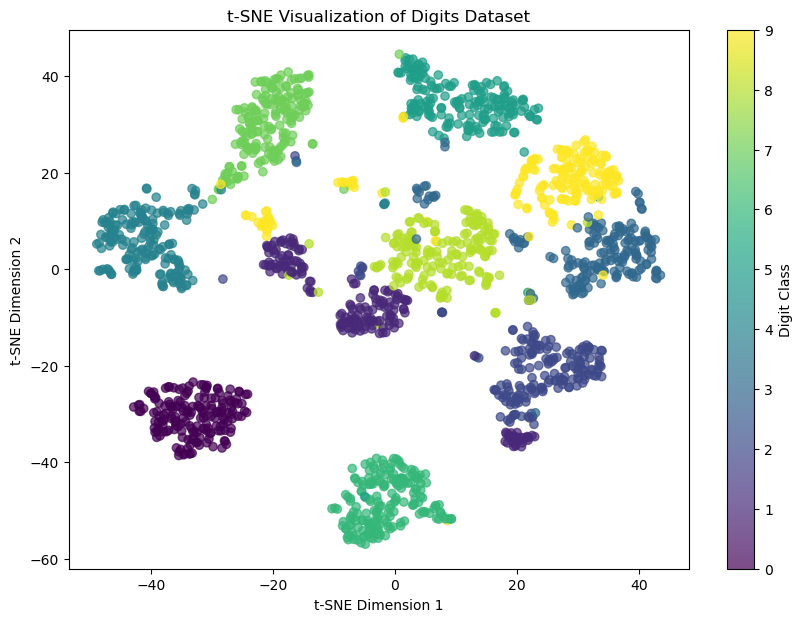

In [7]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Digits Dataset")

plt.colorbar(
    scatter,
    label="Digit Class"
)

plt.show()

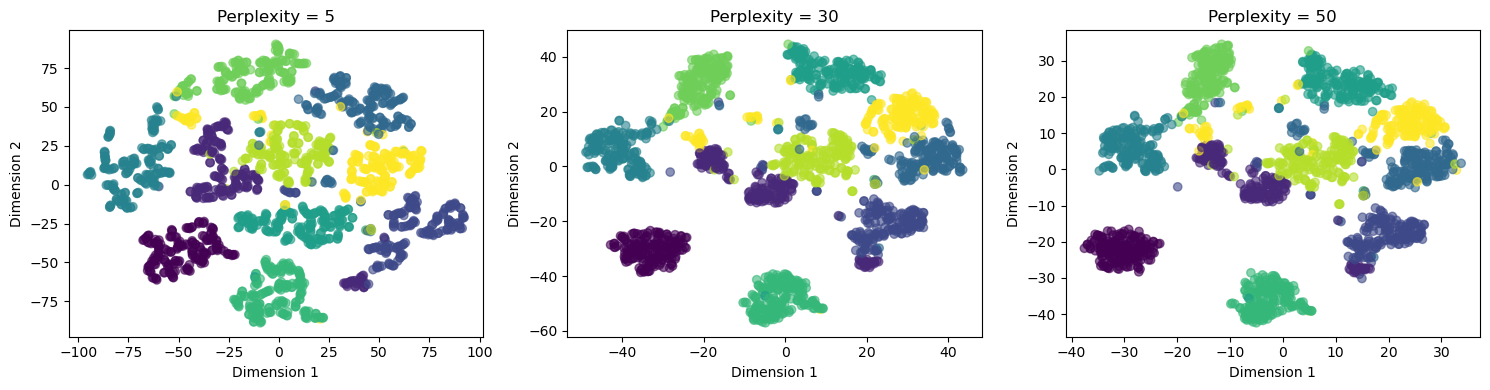

In [8]:
perplexities = [5, 30, 50]

plt.figure(figsize=(15, 4))

for i, perplexity in enumerate(perplexities):

    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=42
    )

    embedding = tsne_model.fit_transform(X_pca)

    ax = plt.subplot(1, 3, i + 1)

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        alpha=0.6
    )

    ax.set_title(
        f"Perplexity = {perplexity}"
    )

    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()

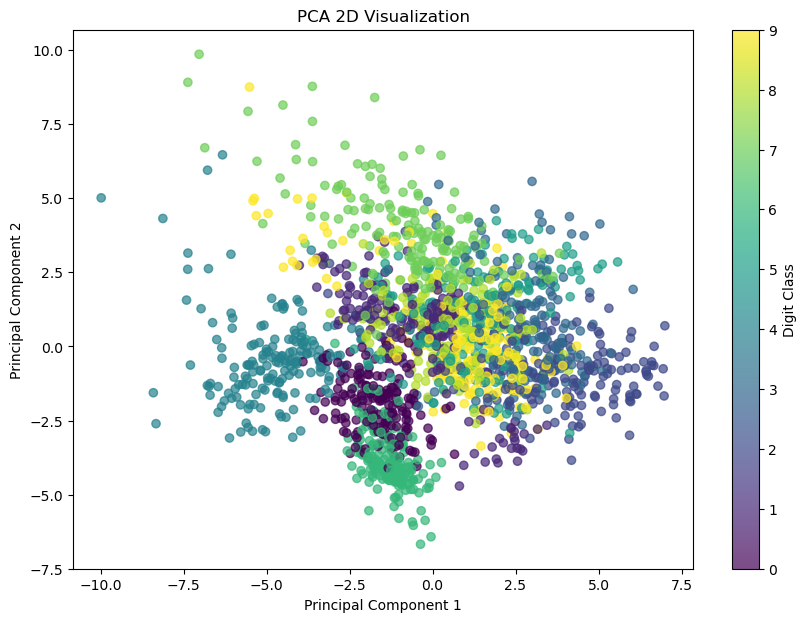

In [9]:
pca_2d = PCA(
    n_components=2,
    random_state=42
)

X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")

plt.colorbar(
    label="Digit Class"
)

plt.show()

## PCA vs t-SNE Comparison

| PCA | t-SNE |
|---|---|
| Linear | Nonlinear |
| Preserves maximum variance | Preserves local neighborhoods |
| Faster | More computationally expensive |
| Useful for preprocessing | Primarily useful for visualization |
| Components are deterministic for fixed preprocessing | Results can vary with initialization and parameters |

## Important Note

t-SNE plots should not be interpreted as exact representations of
global distances between clusters. The algorithm is primarily designed
to reveal local structure.

## Conclusion

- t-SNE is mainly used to visualize high-dimensional datasets.
- It focuses on preserving local neighborhood relationships.
- Perplexity strongly affects the resulting visualization.
- Initialization and random state can influence the result.
- PCA can be useful as preprocessing before t-SNE.
- t-SNE should generally be treated as a visualization technique rather
  than a general-purpose feature transformation for production models.